In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('dataset.csv')
print(df.head())

     OrderID        Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000  2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001  2024-08-23     C75739    Phone         2     151.35   
2  ORD200002  2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003  2023-10-15     C33540    Chair         1     273.19   
4  ORD200004  2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  
2   FREE

In [4]:
print(df.info())
print(df.describe())
print(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
OrderID            1200 non-null object
Date               1200 non-null object
CustomerID         1200 non-null object
Product            1200 non-null object
Quantity           1200 non-null int64
UnitPrice          1200 non-null float64
ShippingAddress    1200 non-null object
PaymentMethod      1200 non-null object
OrderStatus        1200 non-null object
TrackingNumber     1200 non-null object
ItemsInCart        1200 non-null int64
CouponCode         891 non-null object
ReferralSource     1200 non-null object
TotalPrice         1200 non-null float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB
None
          Quantity    UnitPrice  ItemsInCart   TotalPrice
count  1200.000000  1200.000000  1200.000000  1200.000000
mean      2.945833   356.412750     5.485000  1053.968300
std       1.407557   197.177146     2.281983   819.856558
min       1.000000    11.390000 

In [5]:
print(df.duplicated().sum())

0


In [6]:
print(df.median(numeric_only=True))

Quantity         3.000
UnitPrice      364.210
ItemsInCart      5.000
TotalPrice     823.615
dtype: float64


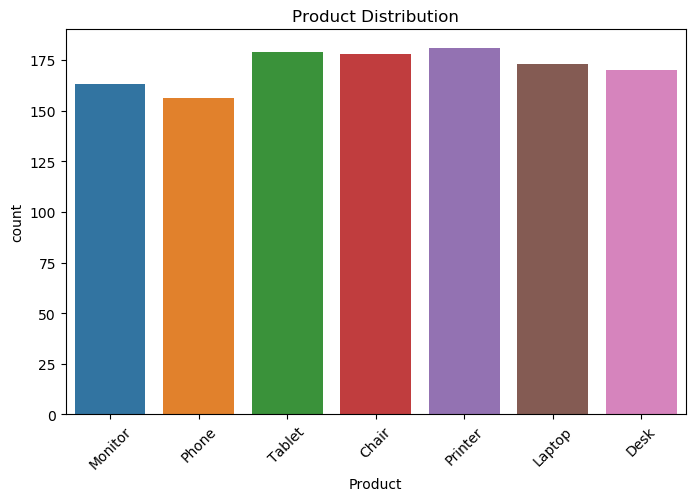

In [7]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Product')
plt.title("Product Distribution")
plt.xticks(rotation=45)
plt.show()

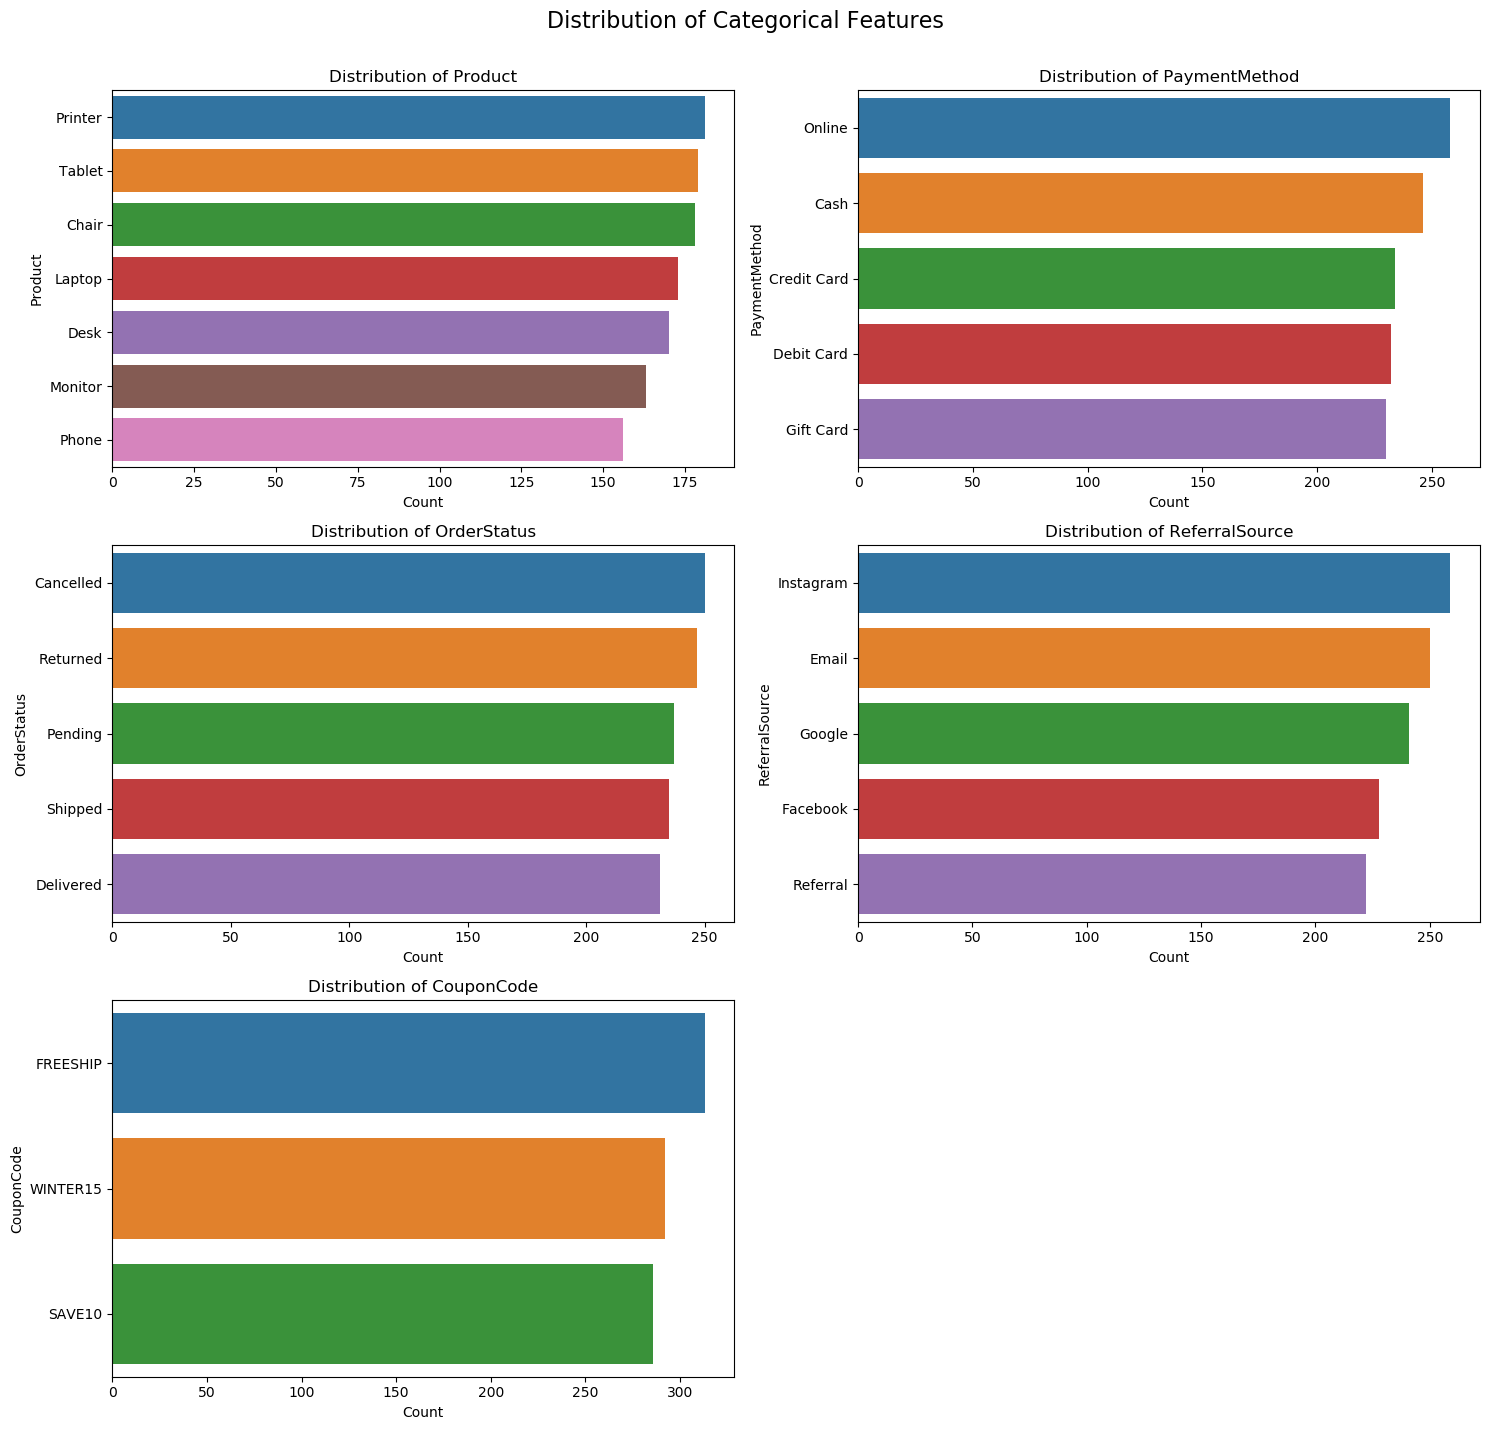

In [8]:
categorical_cols = ['Product', 'PaymentMethod', 'OrderStatus', 'ReferralSource', 'CouponCode']
num_cols = 2 
num_rows = (len(categorical_cols) + num_cols - 1) // num_cols
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
fig.suptitle('Distribution of Categorical Features', fontsize=16)
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    sns.countplot(y=df[col], ax=axes[i], order=df[col].value_counts().index)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel(col)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [9]:
print('Mean for numerical columns:')
display(df[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']].mean())

print('\nMedian for numerical columns:')
display(df[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']].median())

print('\nMode for all columns (top 1 value):')
for col in df.columns:
    print(f'Mode of {col}: {df[col].mode().iloc[0]}')

Mean for numerical columns:


Quantity          2.945833
UnitPrice       356.412750
ItemsInCart       5.485000
TotalPrice     1053.968300
dtype: float64


Median for numerical columns:


Quantity         3.000
UnitPrice      364.210
ItemsInCart      5.000
TotalPrice     823.615
dtype: float64


Mode for all columns (top 1 value):
Mode of OrderID: ORD200000
Mode of Date: 2023-08-20
Mode of CustomerID: C14847
Mode of Product: Printer
Mode of Quantity: 1
Mode of UnitPrice: 127.18
Mode of ShippingAddress: 533 Main St
Mode of PaymentMethod: Online
Mode of OrderStatus: Cancelled
Mode of TrackingNumber: TRK10003020
Mode of ItemsInCart: 5
Mode of CouponCode: FREESHIP
Mode of ReferralSource: Instagram
Mode of TotalPrice: 211.14
